### Gaussian Blue Noise  for Linear Region Counting

In this notebook, we count linear regions using gaussian blue noise sampling as an alternative to iid uniform sampling. We will investigate how the variance and convergence rate of our estimate of the number of linear regions is different from using iid uniform sampling on the input space.

#### Imports:

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
from sklearn.svm import SVC

In [4]:
from scipy.stats import qmc

#### Code to load blue noise samples

Load all the .npy files and sort them into a list of lists:

In [49]:
from pathlib import Path
from itertools import groupby

# 1. Point to your directory
dir_path = Path('/Users/gautamchauhan/Desktop/MSc Project Code/blue_noise_samples')

# 2. Helper function to extract (dimension, sample_size) from a Path object
def get_metadata(path_obj):
    parts = path_obj.stem.split('_')
    return int(parts[3]), int(parts[2])  # Returns (dimension, sample_size)

# 3. Grab all .npy files and sort them immediately by (dimension, sample_size)
sorted_file_paths = sorted(dir_path.glob('*.npy'), key=get_metadata)

# 4. Group by dimension and load the actual arrays into the list of lists
blue_noise_samples = []

for dimension, group in groupby(sorted_file_paths, key=lambda p: get_metadata(p)[0]):
    # Load each numpy file as we build the sublist
    sublist_data = [np.load(str(file_path)) for file_path in group]
    blue_noise_samples.append(sublist_data)

#### Code to set up MLP

Define class for a flexible MLP. It should allow the user to specify:
1. Dimension of the input space
2. Number of hidden neurons in each layer of the network (and therefore number of hidden layers)
3. Whether to use custom (user-provided) initial weights or to set them using Kaiming Normal Distribution (He initialisation)

In [8]:
class MLP(torch.nn.Module):
    def __init__(self,dimensions,neurons_per_hidden,custom_weights=None,custom_biases=None):
        """Set up the neural network model according to the specification given by parameters
        Args:
            dimensions: number of input dimensions
            neurons_per_hidden: 1D array or list containing widths of each layer
            custom_weights: None if Kaiming normal initialisation is to be used, otherwise a list of 2D torch tensors,
                            representing weight matrices to be used between each adjacent pair of layers
            custom_biases: None if Kaiming normal initialisation is to be used, otherwise a list of 1D torch tensors,
                            representing the bias of each neuron in each layer of the neural network
        """
        super().__init__()

        # Create a PyTorch list to store the layers and store the number of neurons per layer
        self.layers = torch.nn.ModuleList()
        self.architecture = neurons_per_hidden

        # Create first hidden layer using dimensions parameter
        hidden1 = torch.nn.Linear(dimensions, neurons_per_hidden[0], bias=True)
        self.layers.append(hidden1)
        self.layers.append(torch.nn.ReLU())
        
        # Create the remaining hidden layers
        for i in range(len(neurons_per_hidden)-1):
            hidden = torch.nn.Linear(neurons_per_hidden[i], neurons_per_hidden[i+1], bias=True)
            self.layers.append(hidden)
            self.layers.append(torch.nn.ReLU())

        # Set initial weights for all layers using user-input or Kaiming normal initialisation
        if custom_weights:
            with torch.no_grad():
                for i in range(len(self.layers)):
                    if isinstance(self.layers[i],torch.nn.Linear):
                        self.layers[i].weight.copy_(custom_weights[int(i/2)])
                        self.layers[i].bias.copy_(custom_biases[int(i/2)])
        else:
            generator = torch.Generator()
            generator.manual_seed(1)
            self.apply(lambda m: self.init_weights(m,generator))

    def init_weights(self, module, generator):
        """Initialise weights according to Kaiming normal distribution and biases according to a uniform distribution
        Args:
            module: the layer to be initialised
            generator: sets a random seed to ensure reproducibility of initial weights
        """
        if isinstance(module, torch.nn.Linear):
            torch.nn.init.kaiming_normal_(module.weight, nonlinearity="relu",generator=generator)
            torch.nn.init.uniform_(module.bias,a=-1.0,b=1,generator=generator)

    
    def forward(self,x):
        """Forward pass through the network to get the activations of each layer for a batch of data
        Args:
            x: a batch of inputs - 2D array of inputs of shape (batch size, input dimension)
        Returns:
            activations: the activations of each neuron in each layer of the network,
                         as a 2D array of shape: (batch size, total number of neurons)
        """
        x = x.float()
        for layer in self.layers:
            x = layer(x)
            # The layers are Linear, ReLU, Linear, ReLU, etc. Store activations after linear layers
            if isinstance(layer,torch.nn.Linear):
                try:
                    activations = np.concatenate((activations,x.detach().numpy()),axis=1)
                # If we have the first layer, initialise the activations array
                except:
                    activations = x.detach().numpy()
        return activations

#### Code to count activation patterns/linear regions:

Create custom PyTorch dataset to process a batch of input points:

In [9]:
class SampleDataset(torch.utils.data.Dataset):
    """Custom dataset designed to store samples to be used in linear region counting"""

    def __init__(self, points):
        # self.points = array of samples of shape (num_points,input dimension)
        self.points = points
        
    def __len__(self):
        return self.points.shape[0]

    def __getitem__(self,index):
        inputs = self.points[index,:]
        return inputs

Function to get numbers of unique linear regions for each sample size:

In [10]:
def region_count(point_sets,model):
    """Count the number of unique linear regions in the input space of a MLP using
    random sample of points from that input space

    Args:
        point_sets: the blue noise point sets of different sizes, of shape (set_size,dimension)
        model: the neural network model we are analysing
    Returns:
        unique_counts: a list of the number of regions found for each set size
        samples_by_region: a dictionary containing each activation pattern and an array of input samples with that pattern
    """

    # Set list to record count for each set size
    # Set dictionary for the activation patterns and the samples corresponding to them
    unique_counts = []
    all_samples_by_region = []

    for sample in point_sets:

        torch_sample = torch.tensor(sample)

        region_count = 0
        samples_by_region = {}

        # Pass the sample through the model and get the activations of each neuron for each input point
        activations = model(torch_sample)

        # For each input point
        for i in range(activations.shape[0]):

            # Get input point
            input_point = sample[i,:]

            # Get the activation pattern from the activation values
            example_values = activations[i,:]
            activation_pattern = ""
            for value in example_values:
                if value > 0:
                    activation_pattern += "1"
                else:
                    activation_pattern += "0"

            # If the activation pattern has already been seen, look up the pattern, add the samples
            # and keep the count the same
            try:
                sample_points = samples_by_region[activation_pattern]
                sample_points = np.vstack((sample_points,input_point))
                samples_by_region[activation_pattern] = sample_points
                region_count = region_count

            # If we haven't seen the pattern before, then trying to access it in the dictionary will
            # raise a KeyError - in this case add the pattern to the dictionary and increase count by 1
            except KeyError:
                
                region_count += 1
                samples_by_region[activation_pattern] = np.array([input_point])

        all_samples_by_region.append(samples_by_region)
        unique_counts.append(region_count)
                            
    return unique_counts, all_samples_by_region

#### Test: run code on simple example neural networks and verify output

Example 1: Put all the functions together to estimate linear region count in a simple neural network with a 2D input, single hidden layer, 2 hidden neurons and specific weights:

In [88]:
dimensions = 2
neurons_per_hidden = [2]
upper_bound = 1
lower_bound = -1
custom_weights = [torch.tensor([[1.0,-1.0],[1.0,1.0]])]
custom_biases = [torch.tensor([0.0,0.0])]

samples = blue_noise_samples[0]
single_samples = []

for sample in samples:
    single_sample = sample[4,:,:]
    single_sample = single_sample*(upper_bound-lower_bound)+lower_bound
    single_samples.append(single_sample)
    
model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
unique_counts, all_samples_by_region = region_count(single_samples,model)

Plot the number of linear regions found in terms of the number of samples:

Text(0, 0.5, 'U(N)')

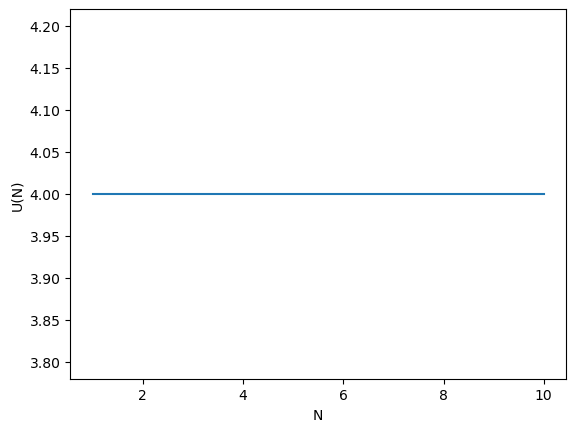

In [89]:
y = unique_counts[0:20]
x = np.arange(1,len(y)+1)
plt.plot(x,y)
plt.xlabel("N")
plt.ylabel("U(N)")

Text(0, 0.5, '$x_{2}$')

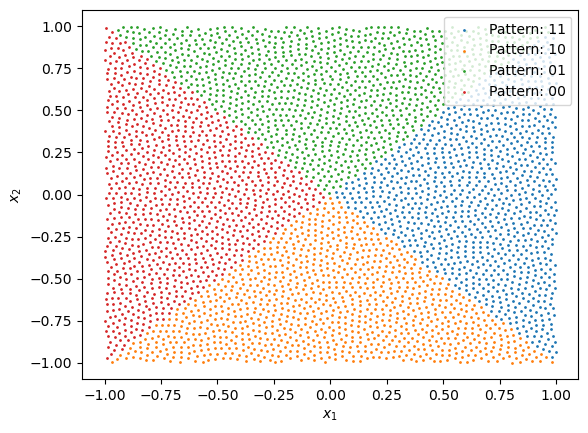

In [97]:
samples_by_region = all_samples_by_region[6]
for pattern in samples_by_region.keys():
    samples = samples_by_region[pattern]
    plt.scatter(samples[:,0],samples[:,1],label=f"Pattern: {pattern}",s=1)
plt.legend()
plt.xlabel(r"$x_{1}$")
plt.ylabel("$x_{2}$")

In this example:
- There are exactly 4 unique linear regions found, which is exactly what we expect from the theory
- The linear regions occupy 4 quadrants of the grid, and the patterns of each quadrant are exactly what we expect from the theory

This demonstrates that the MLP class and region counting function work correctly.

Example 2: The example in Figure 2 from Bounding and Counting Linear Regions of Deep Neural Networks

In [98]:
num_points = 10000
dimensions = 2
neurons_per_hidden = [2,2,2]
custom_weights = [torch.tensor([[-1.0,1.0],[1.0,1.0]]),torch.tensor([[-1.0,-3.0],[-3.0,-1.0]]),torch.tensor([[1.0,3.0],[3.0,1.0]])]
custom_biases = [torch.tensor([0.0,-4.0]),torch.tensor([4.0,4.0]),torch.tensor([-4.0,-4.0])]
lower_bound = -0.5
upper_bound = 4.5

In [110]:
samples = blue_noise_samples[0]
single_samples = []

for sample in samples:
    single_sample = sample[1,:,:]
    single_sample = single_sample*(upper_bound-lower_bound)+lower_bound
    single_samples.append(single_sample)
    
model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
unique_counts, all_samples_by_region = region_count(single_samples,model)

Text(0, 0.5, 'U(N)')

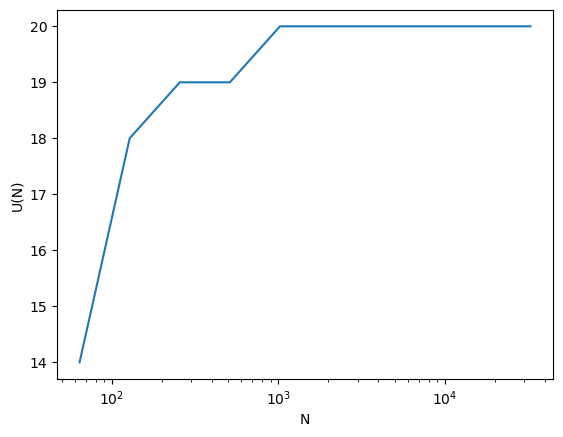

In [111]:
y = unique_counts
x = [2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15]
plt.semilogx(x,y)
plt.xlabel("N")
plt.ylabel("U(N)")

Text(0, 0.5, '$x_{2}$')

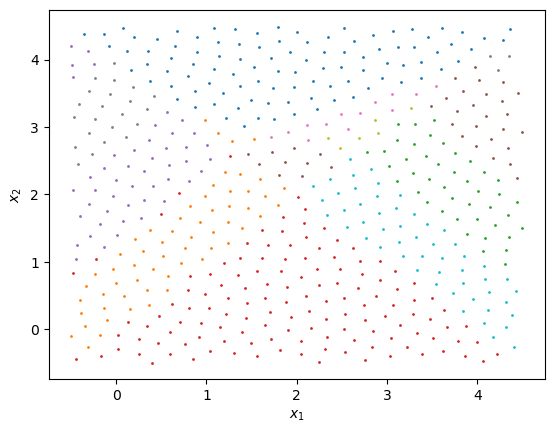

In [112]:
samples_by_region = all_samples_by_region[3]
for pattern in samples_by_region.keys():
    samples = samples_by_region[pattern]
    plt.scatter(samples[:,0],samples[:,1],label=f"Pattern: {pattern}",s=1)
plt.xlabel(r"$x_{1}$")
plt.ylabel("$x_{2}$")

The number of regions and the shape of the regions is exactly the same as shown in the paper (which was done using exact calculations). This provides further evidence that the code works.

Below is a function for an experiment to determine how the variance of the linear regions depends on number of hidden layers and dimension of the input space:

EXPERIMENT 1:
- 100000 samples
- 50 independent runs
- [5,5] neurons per hidden layer
- [2,3,4,5,6,7,8,9,10] dimensions

#### Variance and Dimension Experiments (WITH BIAS)

In [17]:
def experiment_1(blue_noise_samples, neurons_per_hidden, dimensions):
    """Determine how variance of linear region count depends on number of hidden layers and dimension of input space.
    
    Args:
        blue_noise_samples: a list of blue noise samples to use
        neurons_per_hidden: the number of hidden neurons in each layer
        dimensions: the dimension of the input space
    Returns:
        total_unique_counts: the number of linear regions found after each sample
        variances: the run-to-run variance after each number of samples
        total_samples_by_region: the samples for each linear region for all 50 runs
    """

    total_samples_by_region = []
    total_variances = []
    unique_counts_dimension = []
    
    for dimension in dimensions:

        # Get blue noise samples for the current dimension
        blue_noise_by_dimension = blue_noise_samples[dimension-2]
    
        # Initialise the model
        lower_bound = -1
        upper_bound = 1
        
        model = MLP(dimension,neurons_per_hidden)

        num_sizes = len(blue_noise_by_dimension)
        total_unique_counts = np.empty((10,num_sizes))
        
        for j in range(10):
            
            single_samples = []
            # Get all the samples corresponding to run j
            for sample in blue_noise_by_dimension:
                single_sample = sample[j,:,:]
                # Transform from [0,1]^D to [-1,1]^D
                single_sample = single_sample*(upper_bound-lower_bound)+lower_bound
                single_samples.append(single_sample)
                
            unique_counts, all_samples_by_region = region_count(single_samples,model)
            total_unique_counts[j,:] = unique_counts
    
        variances = np.var(total_unique_counts,axis=0)
        total_samples_by_region.append(samples_by_region)
        total_variances.append(variances)
        unique_counts_dimension.append(total_unique_counts)
    
    return unique_counts_dimension, total_variances, total_samples_by_region

EXPERIMENT 1:
- 1 million samples
- 10 independent runs
- [5,5] neurons per hidden layer
- [2,3,4,5,6,7,8,9,10] dimensions

In [141]:
neurons_per_hidden = [5,5]
dimensions = [2,3,4,5,6,7,8,9]

start_time = time.time()
unique_counts_dimension_1, total_variances_1, total_samples_by_region_1 = experiment_1(blue_noise_samples,neurons_per_hidden,dimensions)
end_time = time.time()
time_1 = end_time - start_time

Text(0, 0.5, 'Maximum Variance')

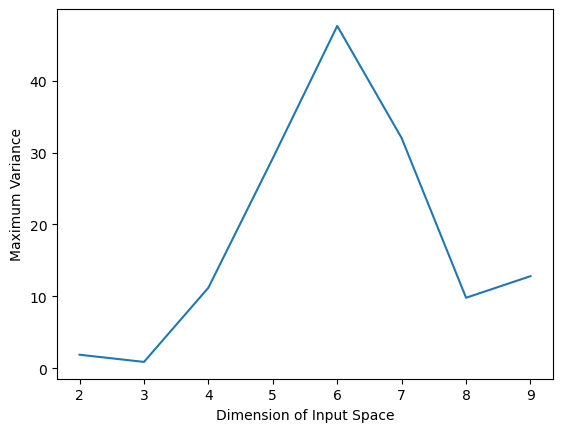

In [142]:
max_variances = [max(variance_array) for variance_array in total_variances_1]
plt.plot(dimensions,max_variances)
plt.xlabel("Dimension of Input Space")
plt.ylabel("Maximum Variance")

In [155]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_1_gbn/counts_1.npy',unique_counts_dimension_1)
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_1_gbn/samples_by_region_1.npy',total_samples_by_region_1)
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_1_gbn/variances_1.npy',total_variances_1)

Compare to iid uniform (using 10 independent runs for fair comparison):

In [29]:
uniform_samples = []
dimensions = [2,3,4,5,6,7,8,9]
sizes = [2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15]
for j in range(len(dimensions)):
    uniform_samples_by_dimension = []
    for i in range(len(sizes)):
        rng = np.random.default_rng(sizes[i])
        uniform_sample = rng.uniform(0,1,size=(10,sizes[i],dimensions[j]))
        uniform_samples_by_dimension.append(uniform_sample)
    uniform_samples.append(uniform_samples_by_dimension)

In [30]:
dimensions = [2,3,4,5,6,7,8,9]
neurons_per_hidden = [5,5]
unique_counts_dimension, total_variances, total_samples_by_region = experiment_1(uniform_samples, neurons_per_hidden, dimensions)

Text(0, 0.5, 'Maximum Variance')

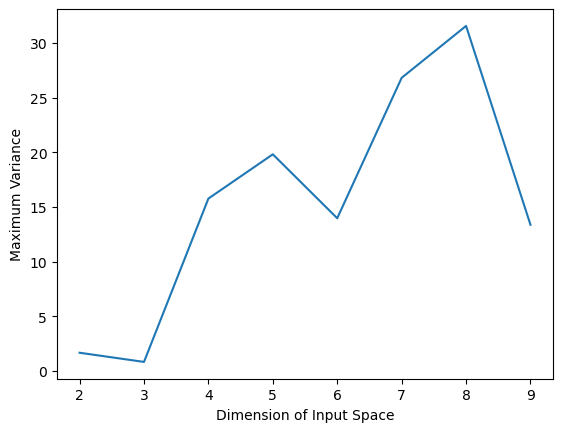

In [31]:
max_variances = [max(variance_array) for variance_array in total_variances]
plt.plot(dimensions,max_variances)
plt.xlabel("Dimension of Input Space")
plt.ylabel("Maximum Variance")

In [52]:
print(unique_counts_dimension[4])

[[ 30.  41.  58.  71.  85.  98. 104. 115. 123. 139.]
 [ 31.  39.  58.  70.  78.  91. 106. 119. 125. 132.]
 [ 34.  44.  54.  68.  84.  92. 102. 115. 122. 130.]
 [ 32.  45.  60.  66.  83.  99. 107. 107. 124. 133.]
 [ 31.  43.  63.  72.  77.  93. 107. 115. 129. 131.]
 [ 33.  46.  55.  79.  87.  89. 100. 115. 127. 134.]
 [ 31.  45.  58.  76.  81.  92. 102. 116. 122. 133.]
 [ 27.  46.  56.  76.  83.  91. 106. 113. 128. 129.]
 [ 26.  39.  58.  73.  79.  97. 108. 111. 124. 141.]
 [ 26.  41.  56.  71.  87.  92. 102. 117. 126. 137.]]


In [35]:
gbn_counts = np.load('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_1_gbn/counts_1.npy')

In [53]:
print(gbn_counts[4])

[[ 34.  50.  55.  68.  85.  99. 103. 111. 115. 131.]
 [ 34.  48.  55.  67.  82.  96. 104. 107. 118. 130.]
 [ 30.  41.  55.  72.  83. 102. 101. 118. 119. 120.]
 [ 34.  40.  58.  74.  88.  97. 101. 113. 130. 131.]
 [ 32.  45.  64.  71.  82. 101. 111. 116. 120. 110.]
 [ 33.  46.  55.  73.  89.  98. 105. 114. 116. 121.]
 [ 32.  46.  57.  72.  88.  98. 105. 111. 125. 124.]
 [ 29.  46.  63.  72.  86.  95. 102. 101. 119. 132.]
 [ 35.  50.  60.  74.  89.  93. 100. 106. 106. 133.]
 [ 36.  47.  63.  76.  81.  98.  98. 112. 118. 128.]]


For dimension 6:

Counts:

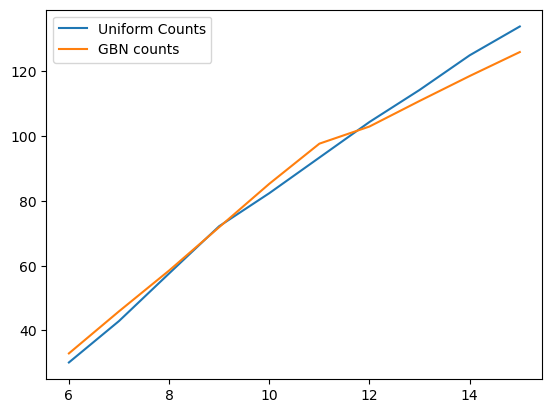

In [67]:
plt.plot(np.log2(sizes),np.mean(unique_counts_dimension[4],axis=0),label="Uniform Counts")
plt.plot(np.log2(sizes),np.mean(gbn_counts[4],axis=0),label="GBN counts")
plt.legend()

Variances:

In [54]:
gbn_variances = np.load('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_1_gbn/variances_1.npy')

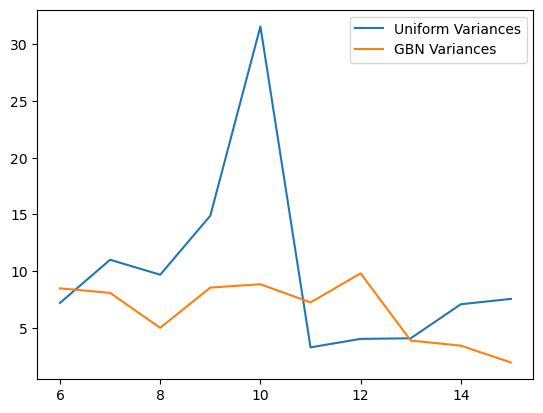

In [71]:
plt.plot(np.log2(sizes),total_variances[6],label="Uniform Variances")
plt.plot(np.log2(sizes),gbn_variances[6],label="GBN Variances")
plt.legend()